In [29]:
!pip install manga-ocr
!pip install deep-translator sentence-transformers

In [8]:
from ultralytics import YOLO
from manga_ocr import MangaOcr
from PIL import Image

model = YOLO("runs/detect/manga_runs/mangaseer_detector2/weights/best.pt")
mocr  = MangaOcr()

img_path = "Manga_Test.png"
results  = model.predict(source=img_path, conf=0.3)
img      = Image.open(img_path)

# Classes to run OCR on — text_bubble is skipped (it wraps the others and causes duplicates)
OCR_CLASSES = {"clean_text", "messy_text"}

# Separate bubble boxes for grouping later
bubble_boxes = []  # list of [x1, y1, x2, y2]
detections   = []  # only OCR-eligible detections

for result in results:
    for box in result.boxes:
        x1, y1, x2, y2 = [int(c) for c in box.xyxy[0].tolist()]
        confidence      = round(box.conf.item(), 2)
        class_name      = result.names[int(box.cls)]

        if class_name == "text_bubble":
            bubble_boxes.append([x1, y1, x2, y2])
            continue  # don't run OCR on the bubble shell itself

        if class_name not in OCR_CLASSES:
            continue

        # Crop and run OCR on tight text region only
        cropped = img.crop((x1, y1, x2, y2))
        text    = mocr(cropped)

        if not text.strip():
            continue

        detection = {
            "text"      : text,
            "bbox"      : [x1, y1, x2, y2],
            "confidence": confidence,
            "class"     : class_name,
        }
        detections.append(detection)
        print(f"[{class_name}] ({confidence}) @ x1={x1} y1={y1} x2={x2} y2={y2} → {text}")

print(f"\n{len(detections)} text regions found | {len(bubble_boxes)} bubbles detected")

2026-04-13 18:17:03.672 | INFO     | manga_ocr.ocr:__init__:16 - Loading OCR model from kha-white/manga-ocr-base
2026-04-13 18:17:04.521 | INFO     | manga_ocr.ocr:__init__:22 - Using CUDA
2026-04-13 18:17:05.019 | INFO     | manga_ocr.ocr:__init__:35 - OCR ready



image 1/1 c:\Users\A\Documents\ML2\Project\Manga_Test.png: 640x448 5 clean_texts, 1 messy_text, 5 text_bubbles, 34.6ms
Speed: 1.1ms preprocess, 34.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 448)
[messy_text] (0.95) @ x1=23 y1=397 x2=66 y2=468 → めっちゃ綺麗な人
[clean_text] (0.93) @ x1=115 y1=521 x2=152 y2=613 → 同じクラスの仁科．．．さん
[clean_text] (0.92) @ x1=395 y1=543 x2=431 y2=620 → あきくん？この人は？
[clean_text] (0.91) @ x1=35 y1=596 x2=66 y2=668 → えっとこっちは．．．
[clean_text] (0.9) @ x1=53 y1=59 x2=83 y2=115 → 誰？
[clean_text] (0.53) @ x1=226 y1=527 x2=244 y2=631 → あきくん．．．．．

6 text regions found | 5 bubbles detected


In [13]:
def find_parent_bubble(text_box, bubble_boxes):
    """Returns the index of the bubble containing this text box, or None."""
    tx1, ty1, tx2, ty2 = text_box
    for i, (bx1, by1, bx2, by2) in enumerate(bubble_boxes):
        if tx1 >= bx1 and ty1 >= by1 and tx2 <= bx2 and ty2 <= by2:
            return i
    return None

def group_detections_by_bubble(detections, bubble_boxes):
    """
    Groups clean_text/messy_text lines sharing the same parent bubble.
    Lines inside the same bubble are sorted top-to-bottom and concatenated.
    Detections not inside any bubble are kept as-is.
    """
    bubble_groups = {}  # bubble_index -> list of detections
    ungrouped     = []

    for d in detections:
        parent = find_parent_bubble(d["bbox"], bubble_boxes)
        if parent is not None:
            bubble_groups.setdefault(parent, []).append(d)
        else:
            ungrouped.append(d)

    grouped = []
    for bubble_idx, group in bubble_groups.items():
        # Sort top-to-bottom so lines read in natural order
        group.sort(key=lambda d: d["bbox"][1])
        combined_text = "　".join(d["text"] for d in group)  # ideographic space as separator
        avg_conf      = round(sum(d["confidence"] for d in group) / len(group), 2)
        grouped.append({
            "text"      : combined_text,
            "bbox"      : bubble_boxes[bubble_idx],  # use parent bubble bbox for visualization
            "confidence": avg_conf,
            "class"     : group[0]["class"],
        })

    return grouped + ungrouped

grouped_detections = group_detections_by_bubble(detections, bubble_boxes)
print(f"{len(detections)} raw detections -> {len(grouped_detections)} grouped entries after bubble merging")

6 raw detections -> 6 grouped entries after bubble merging


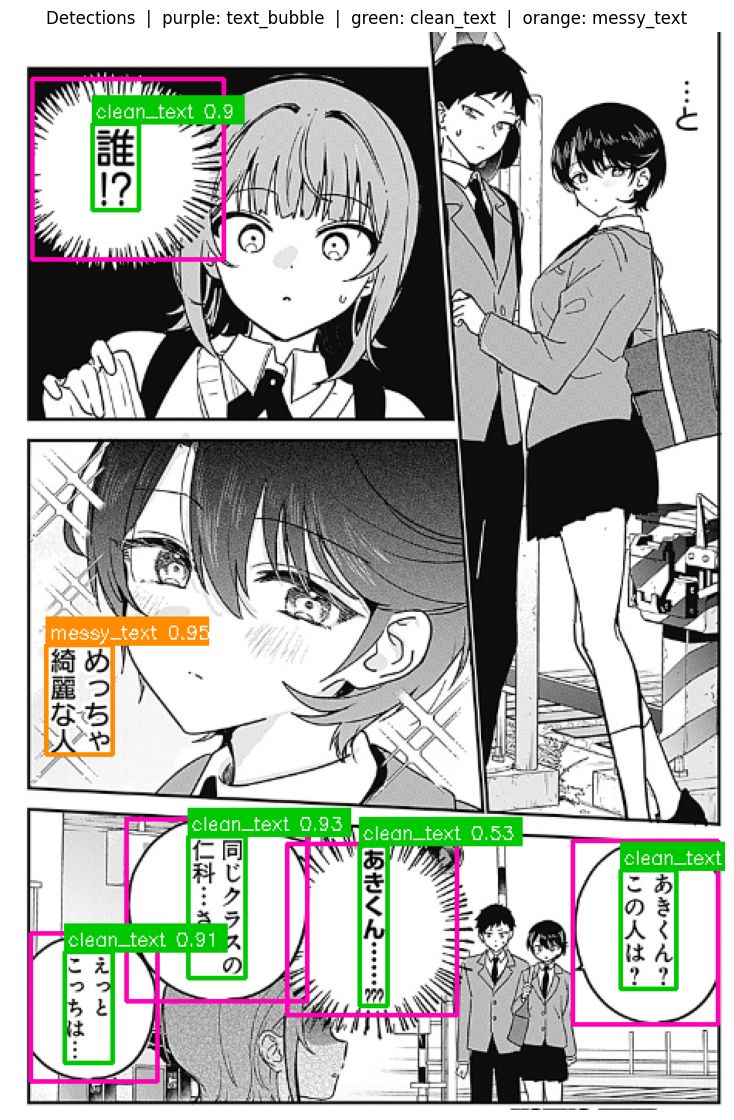


--- OCR Text per Region ---
Box 1 [messy_text]: めっちゃ綺麗な人
Box 2 [clean_text]: 同じクラスの仁科．．．さん
Box 3 [clean_text]: あきくん？この人は？
Box 4 [clean_text]: えっとこっちは．．．
Box 5 [clean_text]: 誰？
Box 6 [clean_text]: あきくん．．．．．


In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Color per class (RGB for matplotlib)
COLORS = {
    "clean_text"  : (0,   200,   0),   # green
    "messy_text"  : (255, 140,   0),   # orange
    "text_bubble" : (180,   0, 255),   # purple
}

img_cv = cv2.imread(img_path)
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

# Draw bubble outlines in purple first (background layer)
for bx1, by1, bx2, by2 in bubble_boxes:
    cv2.rectangle(img_cv, (bx1, by1), (bx2, by2),
                  COLORS["text_bubble"][::-1], 2)  # flip to BGR for cv2

# Draw OCR-eligible detections on top with their class color
for d in detections:
    x1, y1, x2, y2 = d["bbox"]
    color_rgb = COLORS.get(d["class"], (255, 255, 255))
    color_bgr = color_rgb[::-1]
    cv2.rectangle(img_cv, (x1, y1), (x2, y2), color_rgb, 2)
    label = f"{d['class']} {d['confidence']}"
    cv2.rectangle(img_cv, (x1, y1 - 18), (x1 + len(label) * 7, y1), color_rgb, -1)
    cv2.putText(img_cv, label, (x1 + 2, y1 - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

plt.figure(figsize=(14, 14))
plt.imshow(img_cv)
plt.axis("off")
plt.title("Detections  |  purple: text_bubble  |  green: clean_text  |  orange: messy_text")
plt.show()

print("\n--- OCR Text per Region ---")
for i, d in enumerate(detections):
    print(f"Box {i+1} [{d['class']}]: {d['text']}")

In [15]:
from deep_translator import GoogleTranslator
from sentence_transformers import SentenceTransformer, util

embedder   = SentenceTransformer("LaBSE")
translator = GoogleTranslator(source="ja", target="en")

def run_pipeline(detections):
    results = []

    for i, d in enumerate(detections):
        japanese_text = d["text"]

        if not japanese_text.strip():
            continue

        # Step 1 - Translate
        english_text = translator.translate(japanese_text)

        # Step 2 - Embed both
        emb_ja = embedder.encode(japanese_text, convert_to_tensor=True)
        emb_en = embedder.encode(english_text,  convert_to_tensor=True)

        # Step 3 - Cosine similarity
        score = util.cos_sim(emb_ja, emb_en).item()

        results.append({
            "box"        : i + 1,
            "bbox"       : d["bbox"],
            "class"      : d["class"],
            "japanese"   : japanese_text,
            "english"    : english_text,
            "confidence" : d["confidence"],
            "similarity" : round(score, 4),
        })

    return results

In [16]:
# Run pipeline on grouped_detections so multi-line bubbles are translated as one sentence
pipeline_results = run_pipeline(grouped_detections)

In [ ]:
import pandas as pd

df = pd.DataFrame(pipeline_results)[
    ["box", "class", "japanese", "english", "similarity", "confidence"]
]

def color_similarity(val):
    if val >= 0.85:
        return "background-color: #c6efce"  # green - high similarity
    elif val >= 0.70:
        return "background-color: #ffeb9c"  # yellow - small errors
    else:
        return "background-color: #8B0000"  # red - likely mistranslation

# .map() replaces the deprecated .applymap()
df.style.map(color_similarity, subset=["similarity"])

,box,class,japanese,english,similarity,confidence
0,1,clean_text,同じクラスの仁科．．．さん,Nishina in the same class. ．． ．． Mr. Miss.,0.626300,0.930000
1,2,clean_text,あきくん？この人は？,Aki-kun? Who is this person?,0.881700,0.920000
2,3,clean_text,えっとこっちは．．．,"Well, this one. ．． ．．",0.828500,0.910000
3,4,clean_text,誰？,who?,0.958100,0.900000
4,5,clean_text,あきくん．．．．．,Aki-kun. ．． ．． ．． ．．,0.871000,0.530000
5,6,messy_text,めっちゃ綺麗な人,very beautiful person,0.956900,0.950000
